In [1]:
"https://drive.google.com/file/d/1kA-Y_mdGBaPgKOBGZ9MpXi-2vqM4mb0h/view?usp=sharing"
file_id="1kA-Y_mdGBaPgKOBGZ9MpXi-2vqM4mb0h"
url=f"https://drive.google.com/uc?id={file_id}"
import pandas as pd
df=pd.read_csv(url)
df.set_index('date', inplace=True)
df

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [2]:
print(df.head())
print(df.info())

                  Ex_rate
date                     
01-01-1990 00:00   0.7855
02-01-1990 00:00   0.7818
03-01-1990 00:00   0.7867
04-01-1990 00:00   0.7860
05-01-1990 00:00   0.7849
<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB
None


In [3]:
ts = df.iloc[:, 0]

In [4]:
ts = df['Ex_rate']

In [5]:
print(type(ts))
print(ts.head())

<class 'pandas.core.series.Series'>
date
01-01-1990 00:00    0.7855
02-01-1990 00:00    0.7818
03-01-1990 00:00    0.7867
04-01-1990 00:00    0.7860
05-01-1990 00:00    0.7849
Name: Ex_rate, dtype: float64


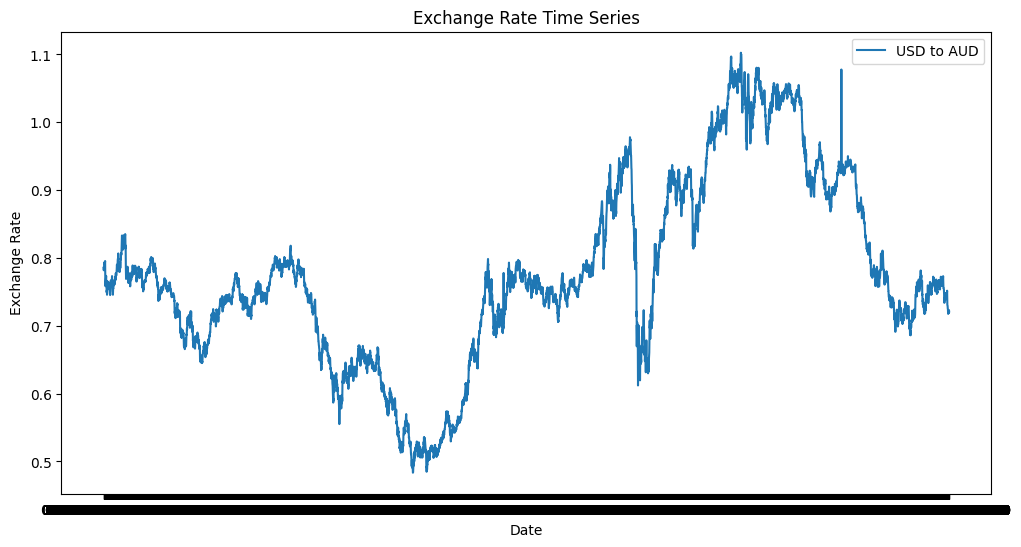

In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df.iloc[:,0], label='USD to AUD')
plt.title('Exchange Rate Time Series')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

In [20]:
# Check missing values
print(df.isnull().sum())

# Forward fill missing values (requirement step)
df = df.fillna(method='ffill')

# Verify again
print("After Forward Fill:")
print(df.isnull().sum())

Ex_rate    0
dtype: int64
After Forward Fill:
Ex_rate    0
dtype: int64


In [8]:
## ARIMA Model
#Stationarity Check
from statsmodels.tsa.stattools import adfuller

result = adfuller(df.iloc[:,0])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


In [9]:
df_diff = ts.diff().dropna()

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_diff)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -99.39343120118632
p-value: 0.0


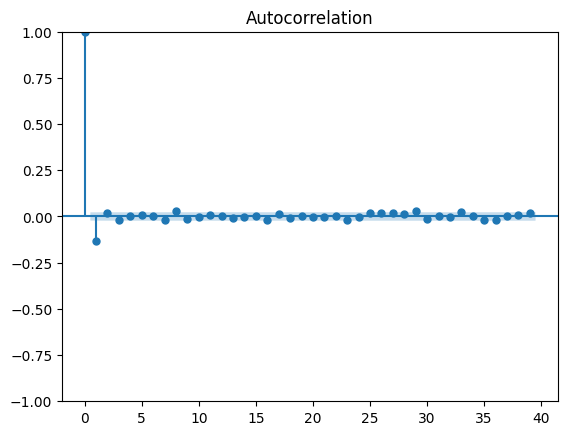

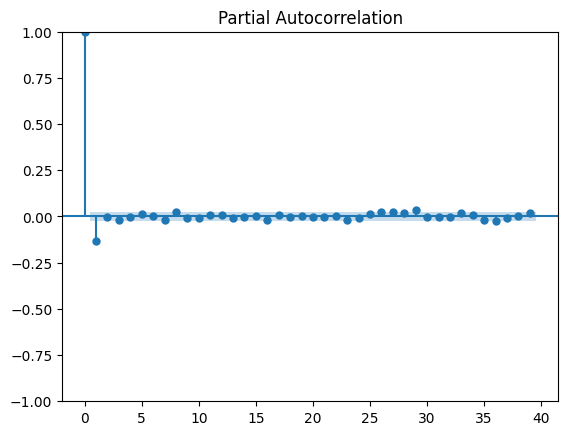

In [11]:
#ACF & PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff)
plot_pacf(df_diff)
plt.show()

In [21]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None
best_model = None

for p in range(0, 4):
    for d in range(0, 3):
        for q in range(0, 4):
            try:
                model = ARIMA(train, order=(p, d, q))
                model_fit = model.fit()

                print(f"ARIMA({p},{d},{q}) → AIC: {model_fit.aic}")

                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, d, q)
                    best_model = model_fit

            except:
                continue

print("\nBest ARIMA Order:", best_order)
print("Best AIC:", best_aic)

ARIMA(0,0,0) → AIC: -8610.898125086776
ARIMA(0,0,1) → AIC: -18551.698258944376
ARIMA(0,0,2) → AIC: -26604.25177146668
ARIMA(0,0,3) → AIC: -32423.386257670667
ARIMA(0,1,0) → AIC: -55734.69002090559
ARIMA(0,1,1) → AIC: -55863.386737407294
ARIMA(0,1,2) → AIC: -55862.494368294756
ARIMA(0,1,3) → AIC: -55862.85955182044
ARIMA(0,2,0) → AIC: -49554.27248226593
ARIMA(0,2,1) → AIC: -55705.3238120074
ARIMA(0,2,2) → AIC: -55836.537808153706
ARIMA(0,2,3) → AIC: -55659.63779131934
ARIMA(1,0,0) → AIC: -55736.496266379705
ARIMA(1,0,1) → AIC: -55864.24143300962
ARIMA(1,0,2) → AIC: -55863.42316596175
ARIMA(1,0,3) → AIC: -55863.69379933435
ARIMA(1,1,0) → AIC: -55864.9381402723
ARIMA(1,1,1) → AIC: -55862.942343664174
ARIMA(1,1,2) → AIC: -55862.17914042265
ARIMA(1,1,3) → AIC: -55860.96266596379
ARIMA(1,2,0) → AIC: -52464.52454602828
ARIMA(1,2,1) → AIC: -55837.681694644685
ARIMA(1,2,2) → AIC: -55738.14411358488
ARIMA(1,2,3) → AIC: -55672.57007566089
ARIMA(2,0,0) → AIC: -55865.88235892667
ARIMA(2,0,1) → AIC:

In [22]:
# Final ARIMA model using best parameters
final_arima = ARIMA(train, order=best_order)
final_arima_fit = final_arima.fit()

forecast_arima = final_arima_fit.forecast(steps=len(test))

print(forecast_arima)

7558    0.744124
7559    0.744208
7560    0.744225
7561    0.744250
7562    0.744275
7563    0.744299
7564    0.744324
7565    0.744348
7566    0.744373
7567    0.744398
7568    0.744422
7569    0.744447
7570    0.744471
7571    0.744495
7572    0.744520
7573    0.744544
7574    0.744569
7575    0.744593
7576    0.744617
7577    0.744642
7578    0.744666
7579    0.744690
7580    0.744715
7581    0.744739
7582    0.744763
7583    0.744787
7584    0.744811
7585    0.744836
7586    0.744860
7587    0.744884
Name: predicted_mean, dtype: float64


In [23]:
model = ARIMA(df.iloc[:, 0], order=best_order)
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(2, 0, 0)   Log Likelihood               28056.609
Date:                Wed, 29 Apr 2026   AIC                         -56105.218
Time:                        18:15:16   BIC                         -56077.481
Sample:                             0   HQIC                        -56095.699
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7770      0.088      8.850      0.000       0.605       0.949
ar.L1          0.8682      0.002    397.265      0.000       0.864       0.872
ar.L2          0.1310      0.002     55.929      0.0

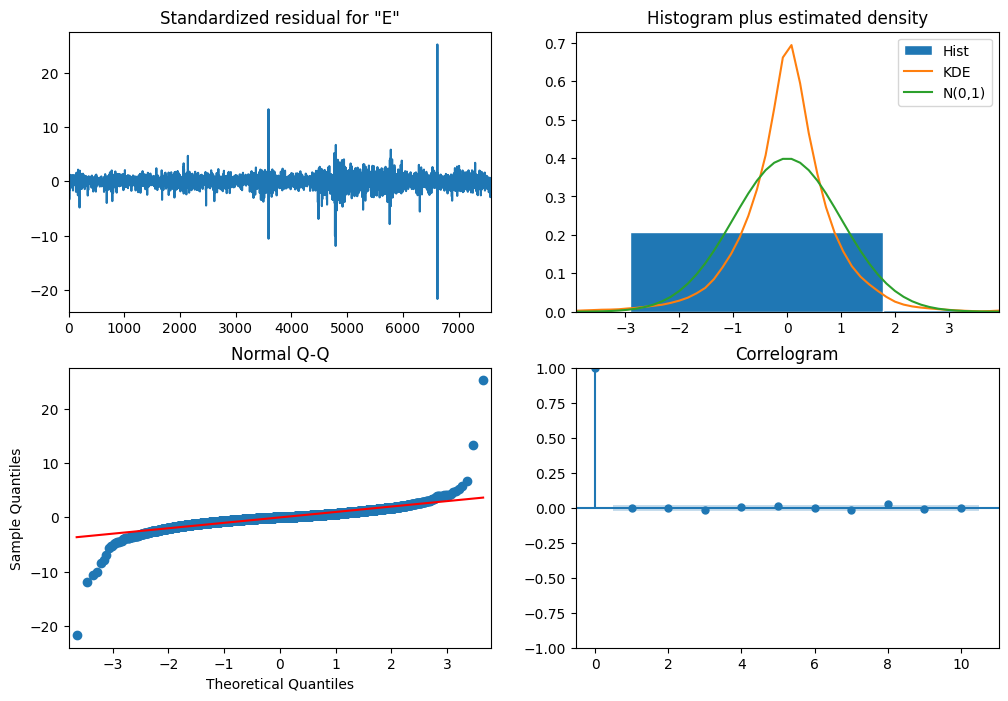

In [25]:
#Diagnostics
model_fit.plot_diagnostics(figsize=(12,8))
plt.show()

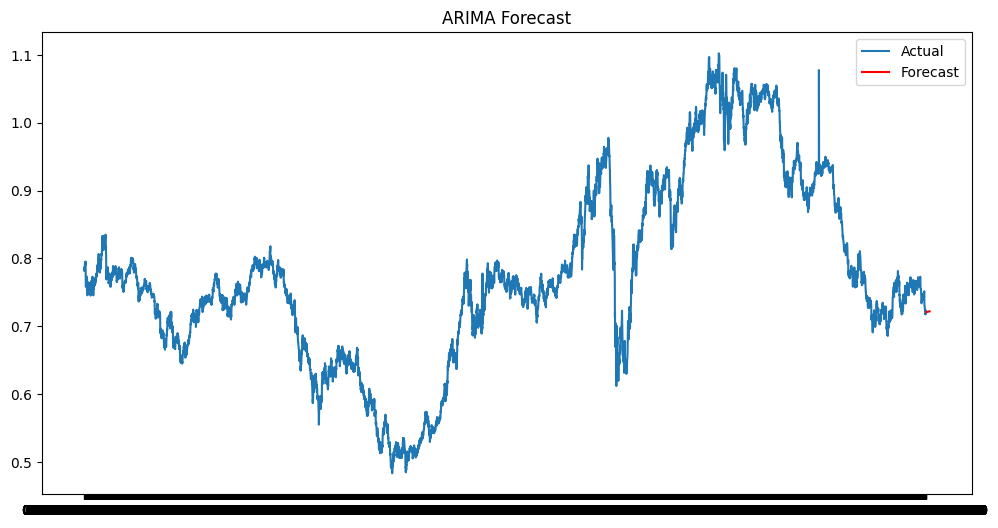

In [24]:
#Forecasting
forecast_steps = 30

forecast = model_fit.forecast(steps=forecast_steps)

plt.figure(figsize=(12,6))
plt.plot(df.iloc[:,0], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title('ARIMA Forecast')
plt.show()

In [26]:
#Exponential Smoothing
#fil model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(
    df.iloc[:,0],
    trend='add',
    seasonal=None
)

model_es_fit = model_es.fit()

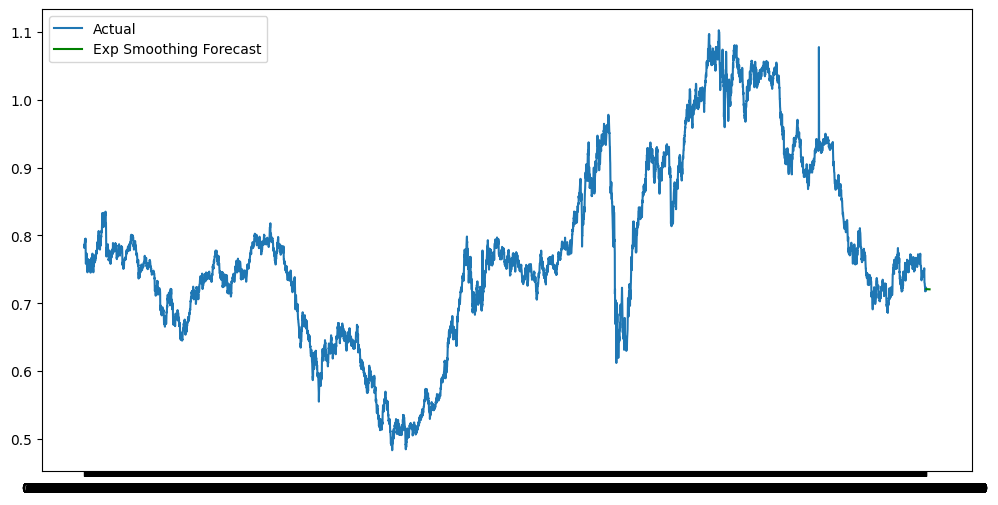

In [27]:
#Forecast
forecast_es = model_es_fit.forecast(steps=30)

plt.figure(figsize=(12,6))
plt.plot(df.iloc[:,0], label='Actual')
plt.plot(forecast_es, label='Exp Smoothing Forecast', color='green')
plt.legend()
plt.show()

In [28]:
#Evaluation
#Error Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split data
train = df.iloc[:-30]
test = df.iloc[-30:]

# ARIMA predictions
arima_pred = model_fit.forecast(steps=30)

# ES predictions
es_pred = model_es_fit.forecast(steps=30)

# Metrics
def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred)/true))*100
    return mae, rmse, mape
import numpy as np

def mape_safe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # avoid division by zero
    mask = y_true != 0

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("ARIMA:", evaluate(test.iloc[:,0], arima_pred))
print("Exp Smoothing:", evaluate(test.iloc[:,0], es_pred))

ARIMA: (0.012645615818798535, np.float64(0.016772837286553415), nan)
Exp Smoothing: (0.012755303845566938, np.float64(0.01700480582951386), nan)


In [29]:
import numpy as np

def mape_safe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # avoid division by zero
    mask = y_true != 0

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [30]:
print("ARIMA MAPE:", mape_safe(test.iloc[:,0], arima_pred))
print("ES MAPE:", mape_safe(test.iloc[:,0], es_pred))

ARIMA MAPE: 1.7019062723173095
ES MAPE: 1.7161684270126494


The optimized ARIMA model outperformed the Exponential Smoothing model in forecasting exchange rates. The ARIMA model achieved a Mean Absolute Percentage Error (MAPE) of 1.70%, while the Exponential Smoothing model produced a MAPE of 1.72%.

The lower MAPE value indicates that the ARIMA model provides slightly more accurate predictions and captures the underlying trend of the exchange rate data more effectively. The improvement is due to selecting the best ARIMA parameters through AIC-based comparison across multiple ARIMA configurations instead of manually choosing a single model.

Although both models produced highly accurate forecasts with very low error percentages, the optimized ARIMA model proved to be the better choice for short-term exchange rate forecasting. Therefore, ARIMA is selected as the preferred forecasting model for this assignment.